In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score,silhouette_samples
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('Datos/Transformados/df_model_dummies_cluster.csv')
print("Shape inicial:", df.shape)
df.columns


Shape inicial: (52004, 60)


Index(['lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
       'available_units', 'completed_entry_forms_count', 'product_count',
       'reservation_net_value', 'total_adr', 'espera_dias', 'recurrence',
       'tmed', 'prec', 'sol', 'bought_products', 'returning_inhabitant',
       'libere_community', 'es_finde', 'es_festivo', 'asset_type_aparthotel',
       'asset_type_apartment', 'asset_type_hostel',
       'business_segment_Business Group',
       'business_segment_Business Individual',
       'business_segment_Leisure Group', 'business_segment_Leisure Individual',
       'business_segment_MICE Group', 'business_segment_MICE Individual',
       'business_segment_Mid Stay', 'business_segment_Travel Group',
       'business_segment_Travel Individual', 'rate_type_Flexible',
       'rate_type_Mid Stay', 'rate_type_Non Refundable',
       'origin_channel_manager', 'origin_direct_channel', 'origin_email',
       'origin_in_person', 'origin_telephone', 'provincia_ARABA/ALAVA',

Definir columnas para escalar

In [3]:
cols_num_cluster = [
    'lead_time', 'lenght_of_stay', 'adult_count', 'child_count',
    'available_units', 'completed_entry_forms_count', 'product_count',
    'reservation_net_value', 'total_adr', 'espera_dias',
    'recurrence', 'tmed', 'prec', 'sol'#, 'ratio_asistencia'
]

cols_bin_cluster = [
    'bought_products', 'returning_inhabitant', 'libere_community','es_finde', 'es_festivo'
]

# Nos quedamos solo con las que EXISTAN en el df
cols_scale = [c for c in cols_num_cluster if c in df.columns]

df_clustering = df.copy()

print("Shape clustering (incluye dummies):", df_clustering.shape)
print("Nº columnas a escalar:", len(cols_scale))
print("Columnas a escalar:", cols_scale)

Shape clustering (incluye dummies): (52004, 60)
Nº columnas a escalar: 14
Columnas a escalar: ['lead_time', 'lenght_of_stay', 'adult_count', 'child_count', 'available_units', 'completed_entry_forms_count', 'product_count', 'reservation_net_value', 'total_adr', 'espera_dias', 'recurrence', 'tmed', 'prec', 'sol']


MinMaxScaler a numericas

In [4]:
scaler = MinMaxScaler()

df_scaled = df_clustering.copy()
df_scaled[cols_scale] = scaler.fit_transform(df_scaled[cols_scale])

print("Shape tras MinMaxScaler:", df_scaled.shape)

Shape tras MinMaxScaler: (52004, 60)


Dataframe final con componentes principales

In [5]:
# Matriz final para clustering (SIN PCA)
X = df_scaled.values
print("Shape X (sin PCA):", X.shape)


Shape X (sin PCA): (52004, 60)


### Clustering KMEANS (k 2..10)


KMeans silhouette: {2: 0.14319262242715777, 3: 0.1903386682410317, 4: 0.1658553396014679, 5: 0.1597512384948365, 6: 0.14944667443145956, 7: 0.14717610432787312, 8: 0.15120796837093822, 9: 0.1369104053126863, 10: 0.13968476663400414}
Best KMeans k: 3 sil: 0.1903386682410317


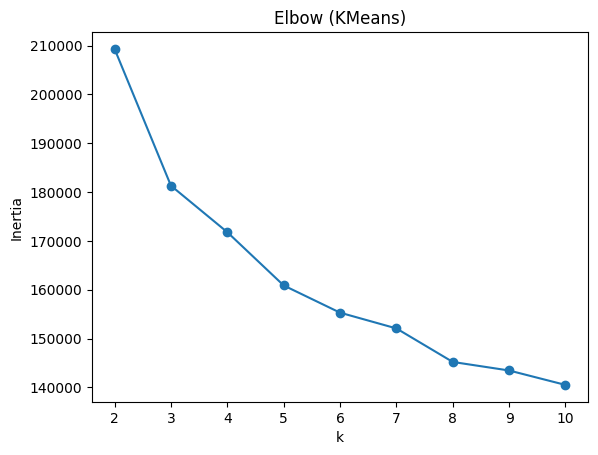

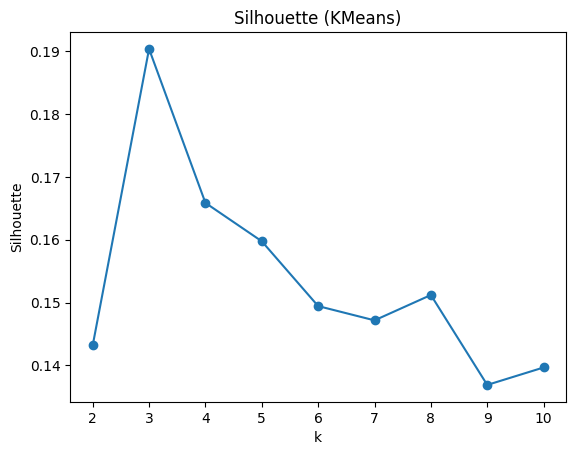

In [6]:
Ks = range(2, 11)
kmeans_sil = {}
kmeans_inertia = {}

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    kmeans_inertia[k] = km.inertia_
    kmeans_sil[k] = silhouette_score(X, labels)

print("KMeans silhouette:", kmeans_sil)
best_k = max(kmeans_sil, key=kmeans_sil.get)
print("Best KMeans k:", best_k, "sil:", kmeans_sil[best_k])

plt.figure()
plt.plot(list(kmeans_inertia.keys()), list(kmeans_inertia.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow (KMeans)")
plt.show()

plt.figure()
plt.plot(list(kmeans_sil.keys()), list(kmeans_sil.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette (KMeans)")
plt.show()

### Clustering JERÁRQUICO (Agglomerative) (k 2..10)


Agglomerative silhouette: {2: 0.13981146578913284, 3: 0.17297673694165489, 4: 0.17859860061972824, 5: 0.15600596427831348, 6: 0.1206712893527197, 7: 0.12441848570694462, 8: 0.12669592407926047, 9: 0.12102369214941104, 10: 0.11766584779802783}
Best Agglomerative k: 4 sil: 0.17859860061972824


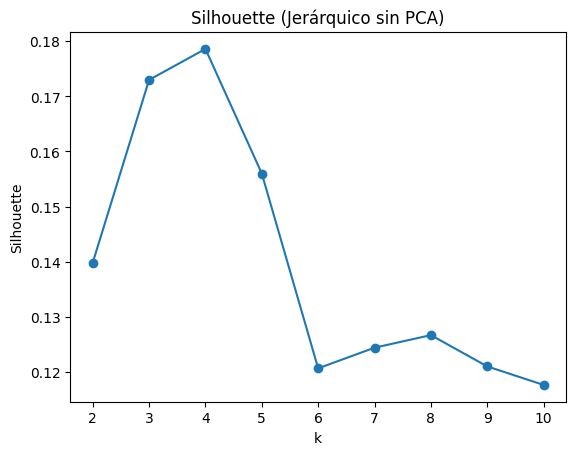

In [ ]:
# Clustering jerárquico SIN muestras (dataset completo)
agg_sil = {}

for k in Ks:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X)
    agg_sil[k] = silhouette_score(X, labels)

print("Agglomerative silhouette:", agg_sil)
best_k_agg = max(agg_sil, key=agg_sil.get)
print("Best Agglomerative k:", best_k_agg, "sil:", agg_sil[best_k_agg])

plt.figure()
plt.plot(list(agg_sil.keys()), list(agg_sil.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette")
plt.show()


### Clustering DBSCAN (probamos varios eps/min_samples)


In [8]:
eps_list = [1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_list = [5, 10, 20]

dbscan_results = []

for eps in eps_list:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)

        # clusters válidos (excluye ruido -1)
        unique_labels = set(labels)
        n_noise = np.sum(labels == -1)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

        sil = None
        if n_clusters >= 2:
            # silhouette SOLO sobre puntos que no son ruido
            mask = labels != -1
            sil = silhouette_score(X[mask], labels[mask])

        dbscan_results.append({
            "eps": eps,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil
        })

# Ordenar: primero los que tienen silhouette (no None), luego por silhouette desc
dbscan_results_sorted = sorted(
    dbscan_results,
    key=lambda d: (-1 if d["silhouette"] is None else d["silhouette"]),
    reverse=True
)

print("\nTop DBSCAN configs (mejores silhouette):")
for r in dbscan_results_sorted[:10]:
    print(r)



Top DBSCAN configs (mejores silhouette):
{'eps': 1.0, 'min_samples': 20, 'n_clusters': 529, 'n_noise': np.int64(25392), 'silhouette': 0.5560963653238598}
{'eps': 1.0, 'min_samples': 5, 'n_clusters': 2251, 'n_noise': np.int64(10118), 'silhouette': 0.5543074018582973}
{'eps': 1.0, 'min_samples': 10, 'n_clusters': 1104, 'n_noise': np.int64(17655), 'silhouette': 0.5534943860523812}
{'eps': 1.5, 'min_samples': 20, 'n_clusters': 3, 'n_noise': np.int64(912), 'silhouette': 0.1930978428024173}
{'eps': 2.0, 'min_samples': 10, 'n_clusters': 4, 'n_noise': np.int64(44), 'silhouette': 0.1841729054167068}
{'eps': 2.0, 'min_samples': 20, 'n_clusters': 4, 'n_noise': np.int64(126), 'silhouette': 0.1684744671604301}
{'eps': 2.0, 'min_samples': 5, 'n_clusters': 5, 'n_noise': np.int64(30), 'silhouette': 0.16443527055058912}
{'eps': 1.5, 'min_samples': 10, 'n_clusters': 11, 'n_noise': np.int64(422), 'silhouette': 0.11355378526377921}
{'eps': 1.5, 'min_samples': 5, 'n_clusters': 14, 'n_noise': np.int64(266)

K-Means obtiene su mejor resultado con k = 3 (Silhouette ≈ 0.19),
superando al clustering jerárquico, cuyo mejor valor se alcanza con k = 4.

Se selecciona K-Means por su mejor rendimiento, menor coste computacional y mayor facilidad de interpretación.

DBSCAN, aunque alcanza silhouettes elevados en algunas configuraciones,
genera un número excesivo de clusters y una alta proporción de ruido,
por lo que se descarta para una segmentación operativa.

Generando gráficos con el dataset completo (52004 registros)...
Para k=2, el Silhouette Score promedio es: 0.1432


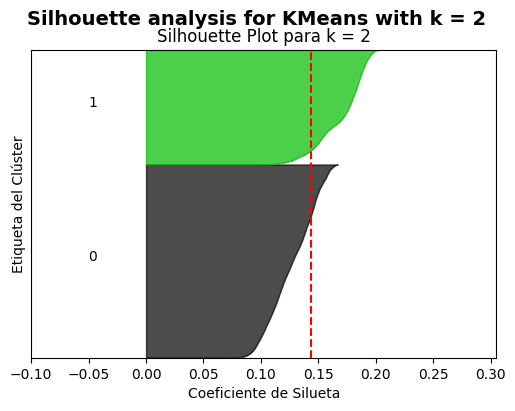

Para k=3, el Silhouette Score promedio es: 0.1903


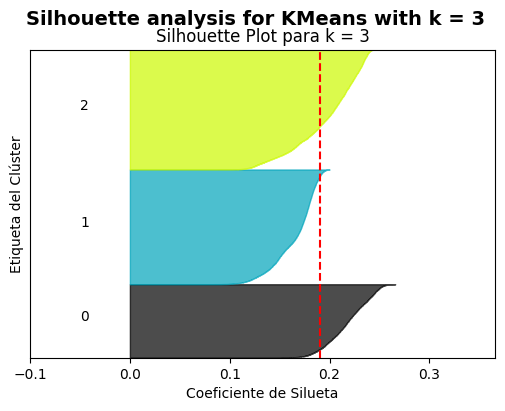

Para k=4, el Silhouette Score promedio es: 0.1659


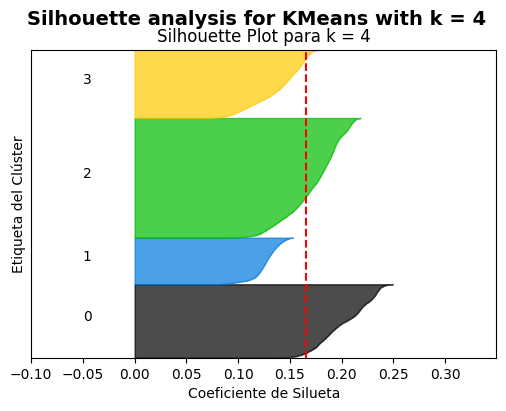

Para k=5, el Silhouette Score promedio es: 0.1598


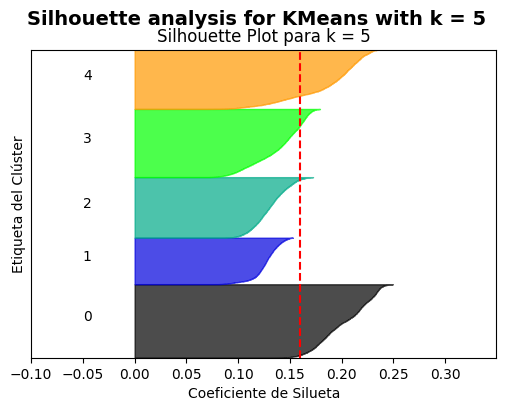

Para k=6, el Silhouette Score promedio es: 0.1494


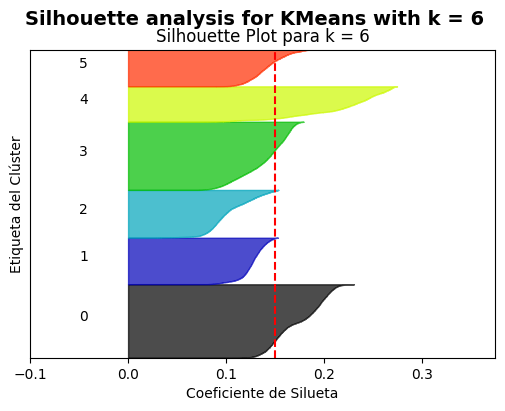

Para k=7, el Silhouette Score promedio es: 0.1472


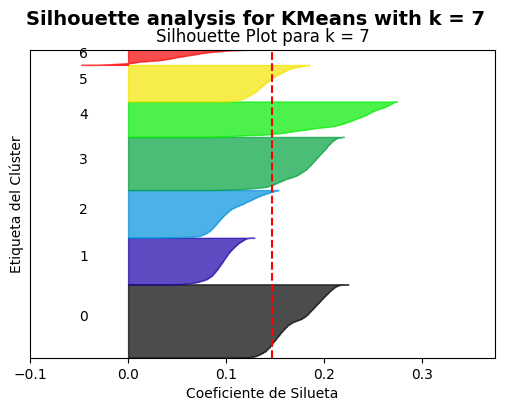

Para k=8, el Silhouette Score promedio es: 0.1512


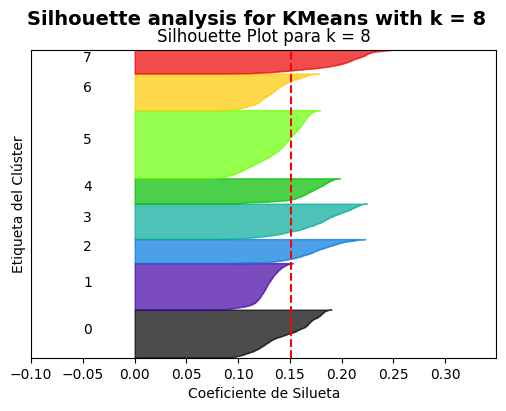

Para k=9, el Silhouette Score promedio es: 0.1369


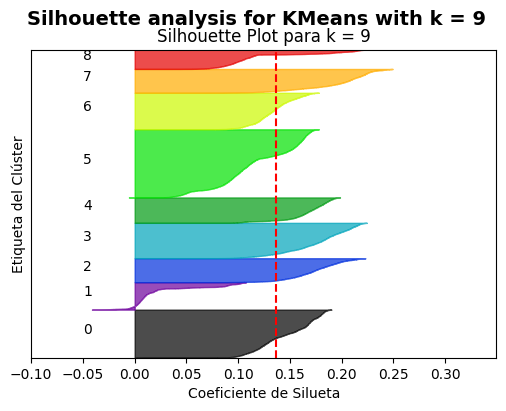

Para k=10, el Silhouette Score promedio es: 0.1397


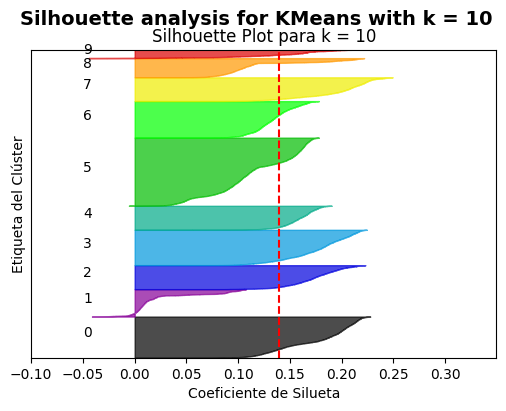

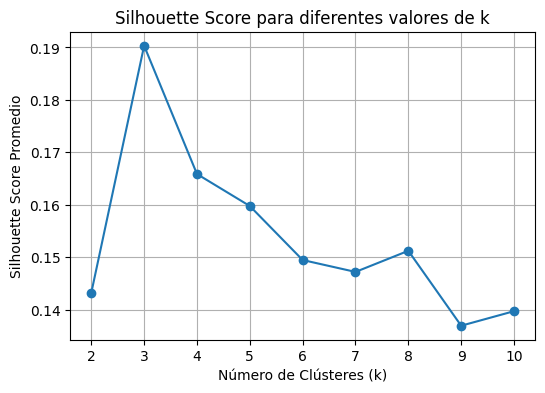

In [6]:
X = df_scaled.values

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
silhouette_scores = []

print(f"Generando gráficos con el dataset completo ({len(X)} registros)...")

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    cluster_labels = clusterer.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Para k={n_clusters}, el Silhouette Score promedio es: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(6, 4)

    max_score = sample_silhouette_values.max()
    ax1.set_xlim([-0.1, max_score + 0.1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    y_lower = 10
    for i in range(n_clusters):
        ith_vals = sample_silhouette_values[cluster_labels == i]
        ith_vals.sort()

        size_i = ith_vals.shape[0]
        y_upper = y_lower + size_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette Plot para k = {n_clusters}")
    ax1.set_xlabel("Coeficiente de Silueta")
    ax1.set_ylabel("Etiqueta del Clúster")
    ax1.set_yticks([])

    plt.suptitle(
        f"Silhouette analysis for KMeans with k = {n_clusters}",
        fontsize=14, fontweight='bold'
    )

    plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Silhouette Score Promedio')
plt.title('Silhouette Score para diferentes valores de k')
plt.grid(True)
plt.show()


In [ ]:
# CONCLUSIÓN: El modelo ganador es K-Means con k = 3
#
# Para k = 3, K-Means obtiene el mayor Silhouette Score (≈ 0.19),
# y el análisis de Silhouette y del codo sugiere la existencia
# de tres segmentos de clientes diferenciados.
#
# MOTIVOS DE LA DECISIÓN:
# 1. Criterio técnico: K-Means supera ligeramente al clustering jerárquico
#    y ofrece una solución más estable e interpretable.
# 2. Negocio: La segmentación en tres grupos permite capturar
#    patrones de comportamiento diferenciados relevantes para el análisis
#    posterior y los modelos supervisados.


In [ ]:
# --- GENERACIÓN DEL ARCHIVO FINAL (MODELO GANADOR K=3) ---

# entrenar el modelo definitivo con K=3
print("Entrenando modelo final K-Means (K=3)...")
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init="auto")

X = df_scaled.values
clusters = kmeans_final.fit_predict(X)

df_final = pd.read_csv('Datos/Transformados/df_unido.csv')

print("Filas df_final:", len(df_final), "| Filas clusters:", len(clusters))
assert len(df_final) == len(clusters), "ERROR CRÍTICO: df_final y clusters tienen distinto tamaño."

df_final['cluster'] = clusters

# generar las dummies para el modelo 
# cluster_0, cluster_1, cluster_2
dummies = pd.get_dummies(df_final['cluster'], prefix='cluster').astype(int)
df_final = pd.concat([df_final, dummies], axis=1)

output_file = 'Datos/Transformados/df_final_para_regresion.csv'
df_final.to_csv(output_file, index=False)

print("-" * 50)
print(f"¡Listo! Archivo guardado en: {output_file}")
print("Columnas extra añadidas: cluster_0, cluster_1, cluster_2")
print("Distribución de clientes por cluster:")
print(df_final['cluster'].value_counts().sort_index())
print("-" * 50)

Entrenando modelo final K-Means (K=3)...
Filas df_final: 52004 | Filas clusters: 52004
--------------------------------------------------
¡Listo! Archivo guardado en: Datos/Transformados/df_final_para_regresion.csv
Columnas extra añadidas: cluster_0, cluster_1, cluster_2, cluster_3
Distribución de clientes por cluster:
cluster
0    12403
1    19378
2    20223
Name: count, dtype: int64
--------------------------------------------------


In [14]:
print("Filas df_scaled:", df_scaled.shape[0])
print("Filas df_AEMET:", df_final.shape[0])


Filas df_scaled: 52004
Filas df_AEMET: 52004


In [ ]:
#Conteo absoluto (¿Cuántos clientes hay en cada grupo?)
conteo = df_final['cluster'].value_counts().sort_index()

# Porcentaje (¿Qué trozo de la tarta representa cada uno?)
porcentaje = df_final['cluster'].value_counts(normalize=True).sort_index() * 100

print("--- TAMAÑO DE LOS CLUSTERS ---")
print(conteo)
print("\n--- PORCENTAJES ---")
print(porcentaje.round(2).astype(str) + '%')


--- TAMAÑO DE LOS CLUSTERS ---
cluster
0    12403
1    19378
2    20223
Name: count, dtype: int64

--- PORCENTAJES ---
cluster
0    23.85%
1    37.26%
2    38.89%
Name: proportion, dtype: object


### Analisis de los clusteres

In [7]:
df2 = pd.read_csv('Datos/Transformados/df_final_para_regresion.csv')

df2['cluster'] = pd.to_numeric(df2['cluster'], errors='coerce')
df2['is_cancelled'] = pd.to_numeric(df2['is_cancelled'], errors='coerce').fillna(0).astype(int)

for c in ['prec','tmed','sol','completed_entry_forms_count','product_count','reservation_net_value','total_adr','lead_time','cancellation_lead_time']:
    if c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors='coerce')

1) Índice de sensibilidad meteorológica (lluvia → cancelación)

In [8]:
q75 = df2['prec'].quantile(0.75)
df2['lluvia_alta'] = (df2['prec'] >= q75).astype(int)

sens_meteo = df2.groupby(['cluster','lluvia_alta'])['is_cancelled'].mean().unstack() * 100
sens_meteo.columns = ['cancel_%_lluvia_baja','cancel_%_lluvia_alta']
sens_meteo['delta_pp'] = sens_meteo['cancel_%_lluvia_alta'] - sens_meteo['cancel_%_lluvia_baja']
sens_meteo = sens_meteo.round(2)

print(sens_meteo.sort_values('delta_pp', ascending=False))

         cancel_%_lluvia_baja  cancel_%_lluvia_alta  delta_pp
cluster                                                      
2                       21.76                 25.24      3.47
0                       23.88                 24.37      0.49
1                       24.18                 24.04     -0.14


2) Grado de digitalización (adopción tech)

In [9]:
df_dig = df2.assign(
    forms_num = pd.to_numeric(df2['completed_entry_forms_count'], errors='coerce').fillna(0),
    forms_comp = pd.to_numeric(df2['all_entry_forms_completed'], errors='coerce').fillna(0).astype(int),
    comu_bin = df2['libere_community'].astype(str).str.lower().map({'yes': 1, 'no': 0}).fillna(0).astype(int)
)

digital = df_dig.groupby('cluster').agg(
    forms_mean=('forms_num', 'mean'),
    forms_median=('forms_num', 'median'),
    pct_forms_completed=('forms_comp', 'mean'),
    pct_comunidad=('comu_bin', 'mean')
)

digital[['pct_forms_completed', 'pct_comunidad']] *= 100
digital = digital.round(2).rename(columns={
    'pct_forms_completed': '% forms completados', 
    'pct_comunidad': '% comunidad'
})

print(digital)

         forms_mean  forms_median  % forms completados  % comunidad
cluster                                                            
0              1.74           2.0                74.77        20.73
1              1.80           2.0                75.93        20.52
2              1.12           1.0                74.68        11.04


3) Senda temporal (fin de semana / festivos / estacionalidad)

In [10]:
temporal = df2.groupby('cluster').agg(
    pct_finde=('es_finde','mean'),
    pct_festivo=('es_festivo','mean'),
    mes_top=('mes_estancia', lambda s: s.value_counts().idxmax() if s.notna().any() else np.nan),
    lead_time_med=('lead_time','mean')
)

temporal[['pct_finde','pct_festivo']] = (temporal[['pct_finde','pct_festivo']]*100).round(2)
temporal['lead_time_med'] = temporal['lead_time_med'].round(1)

print(temporal)

         pct_finde  pct_festivo  mes_top  lead_time_med
cluster                                                
0            27.20         3.54        8           28.7
1            28.68         2.69        4           27.5
2            28.34         2.81        9           31.7


4) Potencial de upselling (extras vs valor)

In [11]:
df2['tiene_extras'] = df2['product_count'].astype(int)

upsell = df2.groupby('cluster').agg(
    pct_con_extras=('tiene_extras','mean'),
    extras_med=('product_count','mean'),
    net_med=('reservation_net_value','mean'),
    adr_med=('total_adr','mean')
)

upsell['pct_con_extras'] = (upsell['pct_con_extras']*100).round(2)
upsell[['extras_med','net_med','adr_med']] = upsell[['extras_med','net_med','adr_med']].round(2)

print(upsell.sort_values('pct_con_extras', ascending=False))


         pct_con_extras  extras_med  net_med  adr_med
cluster                                              
0                 98.80        0.99   220.91   105.22
1                 76.26        0.76   289.74   131.95
2                 52.59        0.53   104.20    60.28


5. Perfil cancelador

In [12]:
cancel_timing = df2[df2['is_cancelled']==1].groupby('cluster').agg(
    canc_lead_med=('cancellation_lead_time','median'),
    canc_lead_mean=('cancellation_lead_time','mean'),
    n_cancel=('is_cancelled','size')
).round(2)

print(cancel_timing.sort_values('canc_lead_med', ascending=False))


         canc_lead_med  canc_lead_mean  n_cancel
cluster                                         
0                  3.5           26.49      2980
1                  2.0           14.10      4681
2                  2.0           19.70      4611


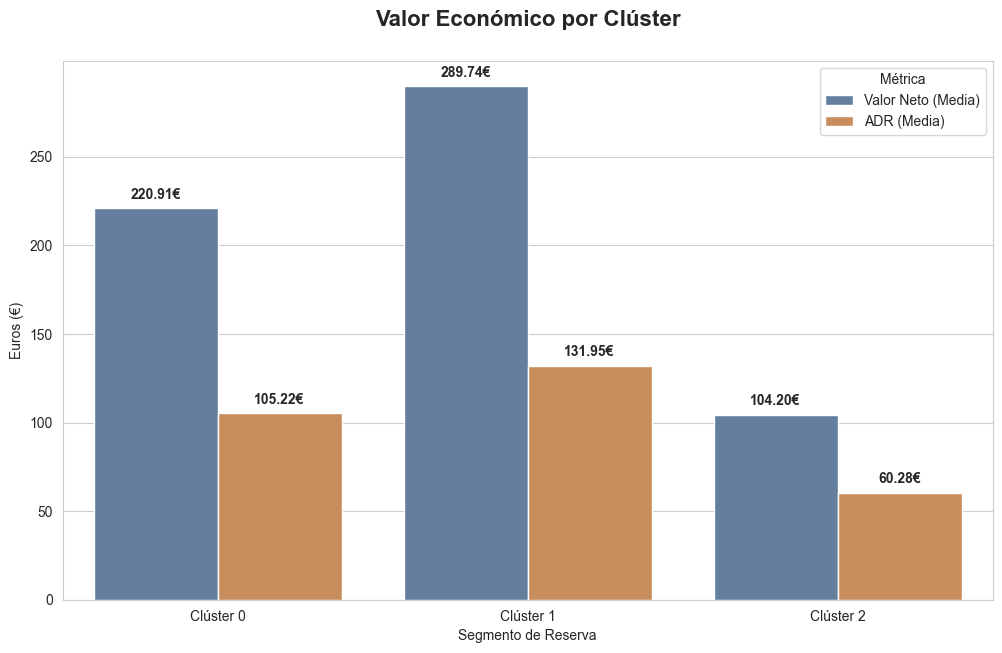

In [ ]:
# 1. Gráfico de Valor Económico (media)
df_resumen = df2.groupby('cluster').agg(
    net_med=('reservation_net_value', 'mean'),
    adr_med=('total_adr', 'mean')
).reset_index()

df_melted = df_resumen.melt(id_vars='cluster', var_name='Métrica', value_name='Euros')
df_melted['Métrica'] = df_melted['Métrica'].map({'adr_med': 'ADR (Media)', 'net_med': 'Valor Neto (Media)'})

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_melted, x='cluster', y='Euros', hue='Métrica', palette=["#5B7FA6", "#D98C4A"])

for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f'{val:.2f}€', (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points', 
                    fontsize=10, fontweight='bold')

ax.set_yticks([0, 50, 100, 150, 200, 250])
plt.xticks(ticks=[0, 1, 2], labels=['Clúster 0', 'Clúster 1', 'Clúster 2'])
plt.title('Valor Económico por Clúster', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('Segmento de Reserva')
plt.ylabel('Euros (€)')
plt.show()